In [268]:
import pandas as pd


In [269]:
df = pd.read_csv('kickstarter_projects.csv')
df

,ID,Name,Category,Subcategory,Country,Launched,Deadline,Goal,Pledged,Backers,State
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed
...,...,...,...,...,...,...,...,...,...,...,...
374848,1486845240,Americas Got Talent - Serious MAK,Music,Hip-Hop,United States,2018-01-02 14:13:09,2018-01-16,500,0,0,Live
374849,974738310,EVO Planner: The World's First Personalized Fl...,Design,Product Design,United States,2018-01-02 14:15:38,2018-02-09,15000,269,8,Live
374850,2106246194,"Help save La Gattara, Arizona's first Cat Cafe!",Food,Food,United States,2018-01-02 14:17:46,2018-01-16,10000,165,3,Live
374851,1830173355,Digital Dagger Coin,Art,Art,United States,2018-01-02 14:38:17,2018-02-01,650,7,1,Live


In [270]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [271]:
df.dtypes #deadline and launched should be timestamps

id             int64
name             str
category         str
subcategory      str
country          str
launched         str
deadline         str
goal           int64
pledged        int64
backers        int64
state            str
dtype: object

In [272]:
df.shape

(374853, 11)

In [273]:
df.head(10)

,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
0,1860890148,Grace Jones Does Not Give A F$#% T-Shirt (limi...,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,625,30,Failed
1,709707365,CRYSTAL ANTLERS UNTITLED MOVIE,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,22,3,Failed
2,1703704063,drawing for dollars,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,35,3,Successful
3,727286,Offline Wikipedia iPhone app,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,145,25,Successful
4,1622952265,Pantshirts,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,387,10,Failed
5,2089078683,New York Makes a Book!!,Journalism,Journalism,United States,2009-04-28 13:55:41,2009-05-16,3000,3329,110,Successful
6,830477146,Web Site for Short Horror Film,Film & Video,Shorts,United States,2009-04-29 02:04:21,2009-05-29,200,41,3,Failed
7,266044220,Help me write my second novel.,Publishing,Fiction,United States,2009-04-29 02:58:50,2009-05-29,500,563,18,Successful
8,1502297238,Produce a Play (Canceled),Theater,Theater,United States,2009-04-29 04:37:37,2009-06-01,500,0,0,Canceled
9,813230527,Sponsor Dereck Blackburn (Lostwars) Artist in ...,Music,Rock,United States,2009-04-29 05:26:32,2009-05-16,300,15,2,Failed


In [274]:
df.sample(10)


,id,name,category,subcategory,country,launched,deadline,goal,pledged,backers,state
135865,881639138,iDiversicons Native App (iPhones & Android Dev...,Design,Graphic Design,United States,2014-04-01 01:40:07,2014-05-31,2000,2037,34,Successful
105300,813016654,PETE SEEGER VS. THE UN-AMERICANS (nonfiction b...,Publishing,Nonfiction,United States,2013-07-29 22:01:53,2013-08-28,10000,10746,196,Successful
171665,496318840,Android Workbench,Technology,Software,United States,2014-09-17 22:24:20,2014-09-30,5000,0,0,Failed
299429,1970904670,Thank You For Being You - Transformational Book,Publishing,Nonfiction,United States,2016-07-19 16:35:56,2016-08-02,5000,729,7,Failed
78416,1815519209,Cafe Twin Show,Film & Video,Film & Video,United States,2012-12-18 00:46:52,2013-01-17,10000,10,1,Failed
209648,1043698186,here in SF : a photo adventure,Photography,Fine Art,United States,2015-03-18 23:42:35,2015-04-10,150,601,19,Successful
118616,671482804,EVIL RISING - A Post-Gay Dark Fantasy,Film & Video,Shorts,United States,2013-11-12 21:36:06,2013-12-12,3000,469,14,Failed
343383,2090952367,The Perfect Notebook,Design,Product Design,United States,2017-05-17 17:01:45,2017-06-12,15000,220172,6676,Successful
203899,248190633,American Snipper - A Barber's Tale (Canceled),Film & Video,Comedy,United States,2015-02-24 23:06:43,2015-04-05,100,0,0,Canceled
241155,1601022223,Adobe Muse Custom Designer Widget,Design,Graphic Design,United States,2015-08-10 20:41:01,2015-09-09,16700,0,0,Failed


In [275]:
df = df.rename(columns= {'state': 'status'})

In [276]:
# This is the target variable
df['status'].value_counts(normalize=True) * 100

status
Failed        52.716932
Successful    35.707597
Canceled      10.337652
Live           0.746426
Suspended      0.491393
Name: proportion, dtype: float64

In [277]:
df['status'].value_counts()


status
Failed        197611
Successful    133851
Canceled       38751
Live            2798
Suspended       1842
Name: count, dtype: int64

In [278]:
help(df['status'].value_counts)

Help on method value_counts in module pandas.core.base:

value_counts(normalize: 'bool' = False, sort: 'bool' = True, ascending: 'bool' = False, bins=None, dropna: 'bool' = True) -> 'Series' method of pandas.Series instance
    Return a Series containing counts of unique values.

    The resulting object will be in descending order so that the
    first element is the most frequently-occurring element.
    Excludes NA values by default.

    Parameters
    ----------
    normalize : bool, default False
        If True then the object returned will contain the relative
        frequencies of the unique values.
    sort : bool, default True
        Stable sort by frequencies when True. Preserve the order of the data
        when False.

        .. versionchanged:: 3.0.0

            Prior to 3.0.0, the sort was unstable.
    ascending : bool, default False
        Sort in ascending order.
    bins : int, optional
        Rather than count values, group them into half-open bins,
        a

In [279]:
round(df.describe(), 0)

,id,goal,pledged,backers
count,3.748530e+05,374853.0,374853.0,374853.0
mean,1.074656e+09,45864.0,9121.0,107.0
std,6.191377e+08,1158778.0,91321.0,912.0
min,5.971000e+03,0.0,0.0,0.0
25%,5.380728e+08,2000.0,31.0,2.0
50%,1.075300e+09,5500.0,625.0,12.0
75%,1.610149e+09,16000.0,4051.0,57.0
max,2.147476e+09,166361391.0,20338986.0,219382.0


In [280]:
round(df[df['status'] == 'Suspended'].describe(), 0)

,id,goal,pledged,backers
count,1.842000e+03,1842.0,1842.0,1842.0
mean,1.095774e+09,175571.0,9323.0,105.0
std,6.147246e+08,3448279.0,99421.0,751.0
min,5.606610e+05,1.0,0.0,0.0
25%,5.808049e+08,1000.0,0.0,0.0
50%,1.102728e+09,5000.0,37.0,2.0
75%,1.626429e+09,20000.0,1346.0,19.0
max,2.147267e+09,100000000.0,4005111.0,20632.0


In [281]:
df.groupby('status').agg({'pledged': 'median', 'backers': 'median', 'goal': 'median' })

,pledged,backers,goal
status,,,
Canceled,87.0,3.0,10000.0
Failed,100.0,3.0,7500.0
Live,259.5,5.0,6523.5
Successful,5109.0,71.0,3840.0
Suspended,37.0,2.0,5000.0


The target variable has 5 values. I think for this business case what's important is for the model to predict either if one business idea "will" success or fail, rather than making this a multivariable classification model. 

In that regard, I would merge canceled with failed as one option, as a canceled project might very well also count as a failed project. A live project (0.7% of total projects) is an incomplete outcome and in that sense it has no predictive value, it still has potential to succeed as well as to fail. Given the small portion of the data it represents, I would discard it from the model. 

Same for the suspended projects. They represent a 0.5% of total projects and, although they could count as nearly failed, we can only compare their values to that of failed projects to decide on whether to convert it but given they small amount they represent, it might not be worth to create synthetic data, hence introducing bias and so, it'd be safer to discard them. Discarding suspended and live projects would mean discarding solely 1.1% of data, which seems a safe margin.

In [282]:
df.isnull().sum()

id             0
name           0
category       0
subcategory    0
country        0
launched       0
deadline       0
goal           0
pledged        0
backers        0
status         0
dtype: int64

In [283]:
len(df[(df[['goal', 'pledged', 'backers']] == 1).any(axis=1)])

35293

In [284]:
len(df[(df[['goal']] == 0).any(axis=1)])

4

All rows with a value of 0 can be count as null values.

In [285]:
#drop all rows with 0
df = df[(df['goal'] != 0)]

In [286]:
df.shape

(374849, 11)

<Axes: >

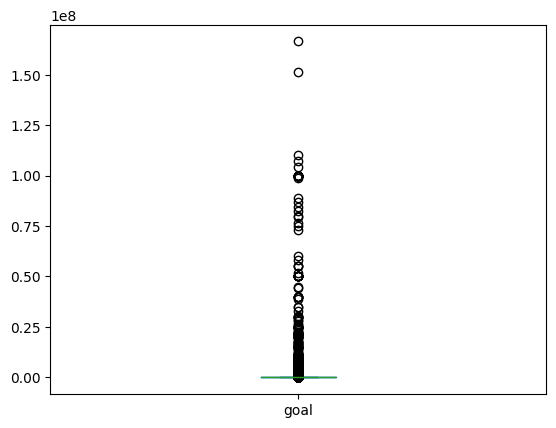

In [287]:
import matplotlib.pyplot as plt  

df['goal'].plot(kind='box')

In [288]:
df['goal'].sort_values().tail(50)

178538     50000000
264144     50000000
238568     50000000
194587     50000000
279244     50000000
342181     51647024
244352     55000000
246236     55000000
241920     55000000
299839     58000000
219594     60000000
152555     73000000
321079     75000000
211790     76286961
220239     79478620
226377     80000000
206463     82624143
189258     84300785
162882     87092841
230031     88767573
371164     99000000
160989    100000000
302692    100000000
265119    100000000
270939    100000000
237936    100000000
282538    100000000
200271    100000000
163907    100000000
294789    100000000
257749    100000000
291797    100000000
356094    100000000
227490    100000000
189486    100000000
356095    100000000
198028    100000000
192058    100000000
248094    100000000
137317    100000000
223121    100000000
317974    100000000
359799    100000000
321074    100000000
145957    100000000
240492    104057190
324187    107369868
243902    110169772
259693    151395870
151823    166361391


In [289]:
df['goal'].quantile([0.90, 0.95, 0.99, 0.999])

0.900      46050.20
0.950      80000.00
0.990     346302.08
0.999    3500000.00
Name: goal, dtype: float64

In [290]:
len(df[df['goal'] > 900000])

1454

In [291]:
df['goal'].describe()

count    3.748490e+05
mean     4.586427e+04
std      1.158784e+06
min      1.000000e+00
25%      2.000000e+03
50%      5.500000e+03
75%      1.600000e+04
max      1.663614e+08
Name: goal, dtype: float64

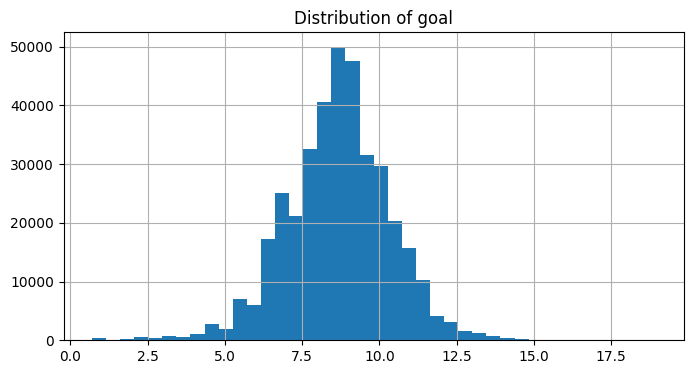

In [292]:
import numpy as np

np.log1p(df['goal']).hist(bins=40, figsize=(8, 4))
plt.title('Distribution of goal')
plt.show()

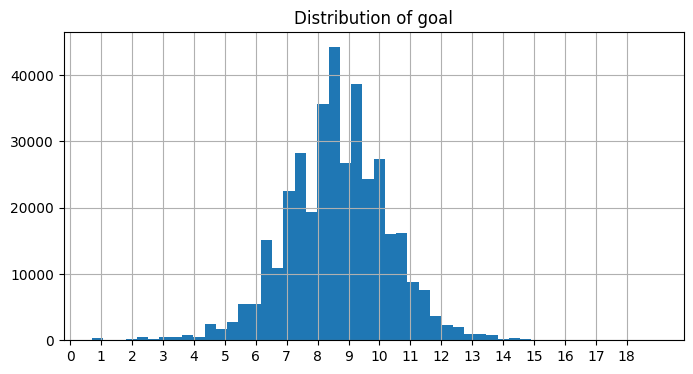

In [293]:
np.log1p(df['goal']).hist(figsize=(8, 4), bins=50)                                                                   
plt.xticks(np.arange(0, 18.5, 1))                                                                                   
plt.title('Distribution of goal')                                                                                     
plt.show() 

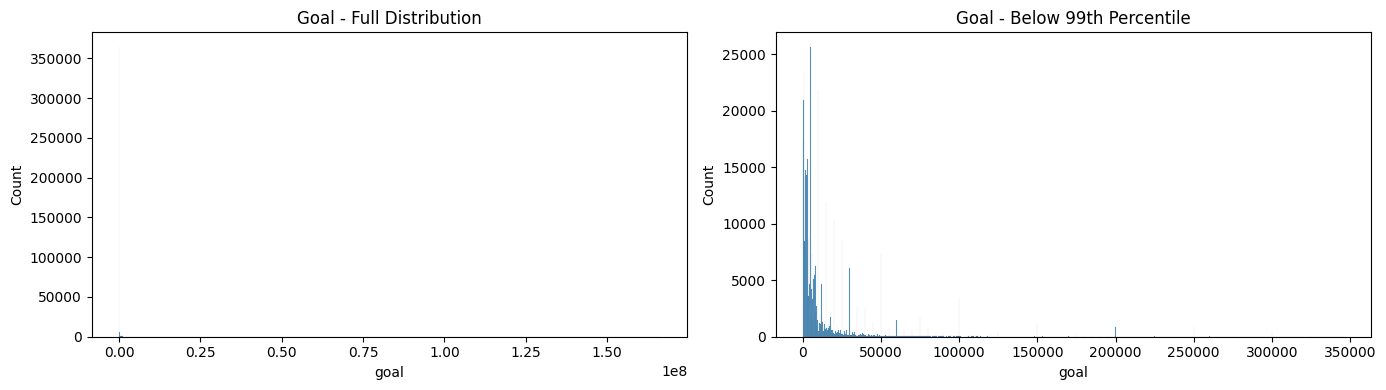

In [294]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
sns.histplot(data=df, x='goal', ax=axes[0])
axes[0].set_title('Goal - Full Distribution')

# Zoomed in (below 99th percentile)
threshold = df['goal'].quantile(0.99)
sns.histplot(data=df[df['goal'] < threshold], x='goal', ax=axes[1])
axes[1].set_title('Goal - Below 99th Percentile')

plt.tight_layout()
plt.show()

The outliers in goal could also be count as error values since realistically they don't happen (or not often enough) for them to be kept and they're most likely bad records.

In [295]:
# To check how many rows to drop
threshold = df['goal'].quantile(0.99)
print(f"Rows dropped: {(df['goal'] >= threshold).sum()}")
print(f"Remaining rows: {(df['goal'] < threshold).sum()}")

Rows dropped: 3749
Remaining rows: 371100


In [296]:
#It accounts to 1% of the whole data set, so it is safe to drop them

df = df[df['goal'] < threshold]

In [297]:
df['goal'].describe()

count    371100.000000
mean      16583.335271
std       32880.946205
min           1.000000
25%        2000.000000
50%        5330.000000
75%       15000.000000
max      346053.000000
Name: goal, dtype: float64

Other columns that don't give any predictive value are the name of the projects and the id. 

Numerical columns like backers and pledged are worth to check their values to keep the rows that contain valid data points but the columns themselves need to be dropped since they would result in data leakage. 
These values are only available after a campaign has ended, meaning our model would never have access to them when making a real prediction at launch time. Keeping them would make our model useless in practice

In [298]:
df = df.drop(['name', 'id'], axis=1)

In [ ]:
df['country'].value_counts()

country
United States     289844
United Kingdom     33331
Canada             14594
Australia           7723
Germany             4110
France              2897
Netherlands         2826
Italy               2822
Spain               2239
Mexico              1743
Sweden              1733
New Zealand         1436
Denmark             1104
Ireland              798
Switzerland          741
Norway               696
Hong Kong            613
Belgium              609
Austria              587
Singapore            553
Luxembourg            61
Japan                 40
Name: count, dtype: int64

In [317]:
df.groupby('country')['status'].value_counts(normalize=True) * 100


country         status    
Australia       Failed        73.444312
                Successful    26.555688
Austria         Failed        81.128748
                Successful    18.871252
Belgium         Failed        74.193548
                Successful    25.806452
Canada          Failed        71.189630
                Successful    28.810370
Denmark         Failed        66.480447
                Successful    33.519553
France          Failed        67.961851
                Successful    32.038149
Germany         Failed        76.563282
                Successful    23.436718
Hong Kong       Failed        61.359571
                Successful    38.640429
Ireland         Failed        73.461538
                Successful    26.538462
Italy           Failed        83.860294
                Successful    16.139706
Japan           Failed        77.419355
                Successful    22.580645
Luxembourg      Failed        68.333333
                Successful    31.666667
Mexico       

In [ ]:
# Drop the rows with values in live and suspended and turn canceled to failed

df['status'] = df['status'].replace('Canceled', 'Failed')

df = df[df['status'].isin(['Failed', 'Successful'])]

In [305]:
df['status'].unique()

<StringArray>
['Failed', 'Successful']
Length: 2, dtype: str

In [308]:
df.subcategory.nunique()

159

In [336]:
df.category.nunique()
df.category.unique()

<StringArray>
[     'Fashion', 'Film & Video',          'Art',   'Technology',
   'Journalism',   'Publishing',      'Theater',        'Music',
  'Photography',        'Games',       'Design',         'Food',
       'Crafts',       'Comics',        'Dance']
Length: 15, dtype: str

In [ ]:
# Drop data leakage columns
df = df.drop(columns=['backers', 'pledged'])

In [318]:
df.head(1)

,category,subcategory,country,launched,deadline,goal,status
0,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,Failed


In [324]:
# Lastly before feature engineering, convert strings to dates

from datetime import datetime

df.launched = pd.to_datetime(df.launched, format='%Y-%m-%d %H:%M:%S')
df.deadline = pd.to_datetime(df.deadline, format='%Y-%m-%d')

In [329]:
df[['launched', 'deadline']].dtypes

launched    datetime64[us]
deadline    datetime64[us]
dtype: object

After all these steps, the data is clean and the remaining columns can be used to shape the model. Next steps are feature engineering and encoding:

In [330]:
# Feature: amount of days between launch and deadline to reach the goal

df['days_to_deadline'] = (df['deadline'] - df['launched']).dt.days

Other features that might be useful are: 

The months when the projects are launched, since these capture recurring temporal patterns that are likely to generalise to future projects. That feature reflects seasonal consumer behaviour and business cycles (i.e. increased consumer spending in holiday season/ lower engagement in summer months). 

Also, the day of the week in which a project is launched, captures weekly rhythms in online activity and consumer attention.

In [331]:
df['month_launched'] = (df.launched).dt.month

In [332]:
df['dayofweek_launched'] = (df.launched).dt.dayofweek

In [333]:
df.head()

,category,subcategory,country,launched,deadline,goal,status,days_to_deadline,month_launched,dayofweek_launched
0,Fashion,Fashion,United States,2009-04-21 21:02:48,2009-05-31,1000,Failed,39,4,1
1,Film & Video,Shorts,United States,2009-04-23 00:07:53,2009-07-20,80000,Failed,87,4,3
2,Art,Illustration,United States,2009-04-24 21:52:03,2009-05-03,20,Successful,8,4,4
3,Technology,Software,United States,2009-04-25 17:36:21,2009-07-14,99,Successful,79,4,5
4,Fashion,Fashion,United States,2009-04-27 14:10:39,2009-05-26,1900,Failed,28,4,0


In [334]:
# I can drop the timestamps columns since they don't give any additional information

df = df.drop(columns=['launched', 'deadline'])

In [335]:
df.head()

,category,subcategory,country,goal,status,days_to_deadline,month_launched,dayofweek_launched
0,Fashion,Fashion,United States,1000,Failed,39,4,1
1,Film & Video,Shorts,United States,80000,Failed,87,4,3
2,Art,Illustration,United States,20,Successful,8,4,4
3,Technology,Software,United States,99,Successful,79,4,5
4,Fashion,Fashion,United States,1900,Failed,28,4,0


Realised that I cleaned the high outliers for statistical justification but didn't take care of the lower end after seeing this table.

In [341]:
df[df['goal'] < 100].sample(20)

,category,subcategory,country,goal,status,days_to_deadline,month_launched,dayofweek_launched
226303,Art,Art,Netherlands,55,Failed,59,5,3
269463,Comics,Graphic Novels,United States,99,Successful,13,1,5
300408,Comics,Comics,United States,15,Successful,22,7,1
40939,Music,Indie Rock,United States,30,Successful,29,1,1
264189,Music,Electronic Music,United States,85,Failed,29,12,0
334149,Theater,Festivals,United States,10,Successful,29,3,6
141009,Design,Product Design,United States,40,Successful,29,5,0
151445,Games,Games,United States,50,Failed,29,7,1
335212,Games,Video Games,United Kingdom,51,Successful,18,3,6
297324,Technology,Technology,United States,10,Successful,41,7,1


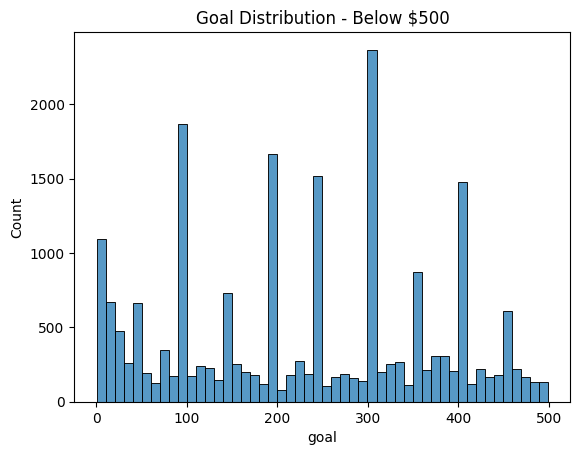

In [342]:
sns.histplot(data=df[df['goal'] < 500], x='goal', bins=50)
plt.title('Goal Distribution - Below $500')
plt.show()

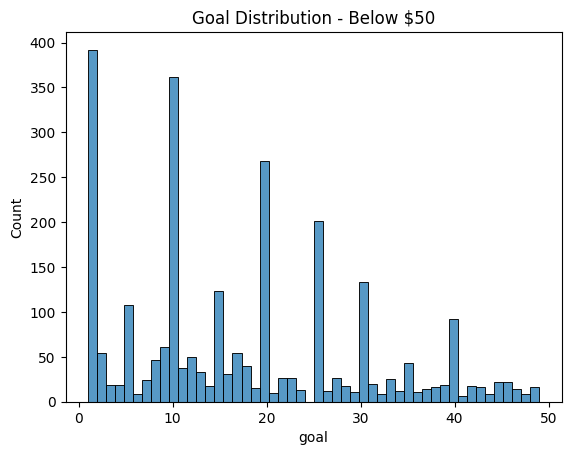

In [343]:
sns.histplot(data=df[df['goal'] < 50], x='goal', bins=50)
plt.title('Goal Distribution - Below $50')
plt.show()

In [344]:
df[df['goal'] < 500].groupby('status')['goal'].count()


status
Failed        10074
Successful    11243
Name: goal, dtype: int64

I chose to keep projects with low funding goals as they appear to be legitimate projects, small creative endeavours with modest ambitions. Unlike the upper end of the distribution where a small number of extreme values created a sharp, isolated spike, the lower end shows a more uniform distribution. Furthermore, the balance between successful and failed projects in this range mirrors the overall dataset, suggesting these are genuine projects rather than data errors.

Next, when thinking about encoding the rest of the columns, I was thinking, how much information is subcategory giving me for prediction? 

I'd have to hot-encode that column (since its valuer aren't ordinal) but that would create 159 columns unless compressed but, what if I drop it altogether? 

In [345]:
df.groupby(['category', 'subcategory'])['status'].apply(lambda x: (x == 'Successful').mean()).unstack(level=0)

category,Art,Comics,Crafts,Dance,Design,Fashion,Film & Video,Food,Games,Journalism,Music,Photography,Publishing,Technology,Theater
subcategory,,,,,,,,,,,,,,,
3D Printing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.372881,NaN
Academic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.212670,NaN,NaN
Accessories,NaN,NaN,NaN,NaN,NaN,0.34917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Action,NaN,NaN,NaN,NaN,NaN,NaN,0.159226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Animals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.255061,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Woodworking,NaN,NaN,0.254577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Workshops,NaN,NaN,NaN,0.316456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
World Music,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.444766,NaN,NaN,NaN,NaN


In [347]:
df.groupby(['category', 'subcategory'])['status'].apply(lambda x: (x == 'Successful').mean())

category  subcategory   
Art       Art               0.417345
          Ceramics          0.438538
          Conceptual Art    0.362103
          Digital Art       0.280000
          Illustration      0.520653
                              ...   
Theater   Immersive         0.533123
          Musical           0.516201
          Plays             0.590308
          Spaces            0.497487
          Theater           0.628298
Name: status, Length: 170, dtype: float64

In [ ]:
# Checking one category to see the spread
df[df['category'] == 'Technology'].groupby('subcategory')['status'].apply(lambda x: (x == 'Successful').mean()).sort_values()

subcategory
Apps                 0.061998
Web                  0.069235
Software             0.127191
Flight               0.194872
Technology           0.202773
Fabrication Tools    0.276596
Gadgets              0.299312
Wearables            0.331058
Makerspaces          0.333333
Hardware             0.344215
3D Printing          0.372881
Space Exploration    0.400685
Robots               0.412844
Sound                0.428571
DIY Electronics      0.471719
Camera Equipment     0.484848
Name: status, dtype: float64

There is a big spread within the category Technology, which indicates that there is some predictive potential in subcategory that category by itself would miss.

In [ ]:
#checking other categories
df[df['category'] == 'Publishing'].groupby('subcategory')['status'].apply(lambda x: (x == 'Successful').mean()).sort_values()

subcategory
Academic             0.212670
Young Adult          0.214464
Translations         0.243056
Fiction              0.245439
Nonfiction           0.270533
Publishing           0.302248
Comedy               0.347222
Children's Books     0.350186
Poetry               0.358616
Calendars            0.400000
Periodicals          0.410359
Radio & Podcasts     0.431072
Zines                0.471053
Literary Journals    0.485401
Art Books            0.511119
Literary Spaces      0.565217
Anthologies          0.587601
Letterpress          0.600000
Name: status, dtype: float64

I choose target encoding for subcategory over one-hot encoding to avoid adding 159 columns to the dataset, and over grouping into "Other" to preserve the meaningful variation in success rates across subcategories within the same category. For example, within Technology, Apps have a 6% success rate while Camera Equipment has 48%. Target encoding captures this signal in a single column by replacing each subcategory with its mean success rate. To avoid data leakage, the encoding is calculated exclusively on the training set and then applied to the test set.

So, next step is to take care of the other categories. Binary encoding for the target variable Status, and after splitting the data, one-hot-encoding for category and country.

In [350]:
# Binary encoding for status

df['status'] = (df['status'] == 'Successful').astype(int)

#### Model creation:

In [352]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

NameError: name 'X' is not defined